In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import glob
import os
import math

In [2]:
H5DIR = "corr_h5_out_claude"
h5files = sorted(glob.glob(H5DIR + "/corr_*.h5"))
print("available ensembles:")
for i, f in enumerate(h5files):
    print(f"  {i}: {os.path.basename(f)}")

available ensembles:
  0: corr_obs_nc4nf1_2448_b10p800_m0p0100.h5
  1: corr_obs_nc4nf1_2448_b10p840_m0p0500.h5
  2: corr_obs_nc4nf1_2448_b10p865_m0p1000.h5
  3: corr_obs_nc4nf1_2448_b10p990_m0p2000.h5
  4: corr_obs_nc4nf1_2448_b11p035_m0p3000.h5
  5: corr_obs_nc4nf1_2448_b11p045_m0p4000.h5


In [3]:
# channel short-label -> h5 channel name
ch_dict = {
    "id":   "I_I",
    "g5":   "G5_G5",
    "gtg5": "GTG5_GTG5",
    "gxg5": "GXG5_GXG5",
    "gyg5": "GYG5_GYG5",
    "gzg5": "GZG5_GZG5",
    "gt":   "GT_GT",
    "gx":   "GX_GX",
    "gy":   "GY_GY",
    "gz":   "GZ_GZ",
}

ens_id = 2
gamma = "g5"          # channel: id, g5, gtg5, gxg5, gyg5, gzg5, gt, gx, gy, gz
psq   = 0             # p^2 class: integer 0 .. 4
contr = "CminusDsub"  # contribution: C, Dsub, or CminusDsub

In [4]:
ch  = ch_dict[gamma]
mom = f"p{psq}"

h5file = h5files[ens_id]
# read the (Nconf, nt) array for <contr>/<ch>/<mom>, rows aligned with confs/<ch>
with h5py.File(h5file, "r") as h:
    beta = float(h["beta"][()])
    mass = float(h["m"][()])
    nc = int(h.attrs.get("Nc", 0))
    data = np.array(h[f"{contr}/{ch}/{mom}"])   # (Nconf, nt)
    confs = np.array(h[f"confs/{ch}"])

ts = np.arange(data.shape[1])
print(f"{os.path.basename(h5file)}  contr={contr} gamma={gamma}(ch={ch}) psq={psq}  Nconf={data.shape[0]}  beta={beta} m={mass} Nc={nc}")

corr_obs_nc4nf1_2448_b10p865_m0p1000.h5  contr=CminusDsub gamma=g5(ch=G5_G5) psq=0  Nconf=178  beta=10.865 m=0.1 Nc=4


In [5]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    return np.mean(resmpld, axis=0)

def meff_est(i, binsize, np_data):
    m = simple_mean(i, binsize, np_data)
    return np.log( m[:-1] / m[1:] )

Text(0.5, 1.0, 'G5_G5  p0   $\\beta$=10.865  $m$=0.1 $N_{\\rm conf}$=178')

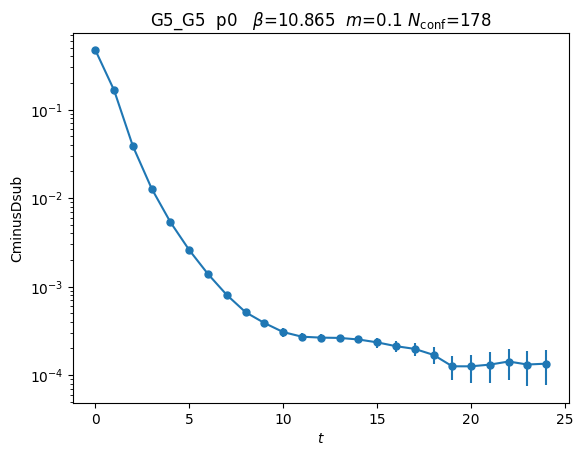

In [6]:
# jackknifed correlator
binsize = 4
jk = Jackknife( data.shape[0], binsize )
jk.set( simple_mean, data )
jk.do_it()
plt.errorbar(ts, jk.mean(), jk.err(), marker='o', markersize=5)
plt.hlines(0.0, ts[0], ts[-1])
plt.yscale("log")
plt.xlabel("$t$")
plt.ylabel(contr)
plt.title(rf"{ch}  {mom}   $\beta$={beta}  $m$={mass} $N_{{\rm conf}}$={data.shape[0]}")

Text(0.5, 1.0, 'G5_G5  p0   $\\beta$=10.865  $m$=0.1  $N_{\\rm conf}$=178')

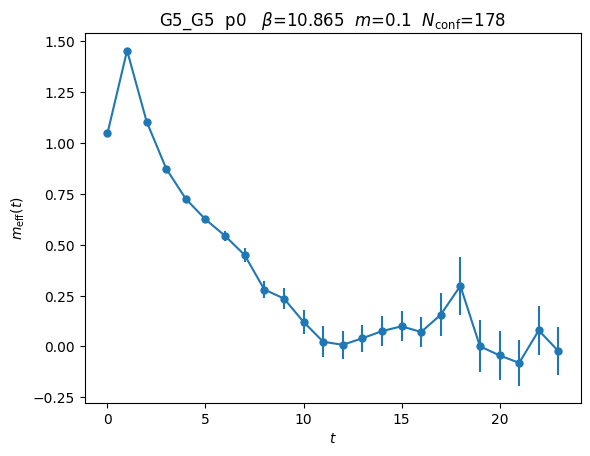

In [7]:
# effective mass m_eff(t) = log[(C-D)(t)/(C-D)(t+1)], jackknifed via the Jackknife routine.
# nan appears where the correlator crosses zero into the noise floor (large t).
binsize = 4
jkm = Jackknife( data.shape[0], binsize )
jkm.set( meff_est, data )
jkm.do_it()
tm = np.arange(data.shape[1] - 1)
plt.errorbar(tm, jkm.mean(), jkm.err(), marker='o', markersize=5)
plt.xlabel("$t$")
plt.ylabel(r"$m_{\rm eff}(t)$")
plt.title(rf"{ch}  {mom}   $\beta$={beta}  $m$={mass}  $N_{{\rm conf}}$={data.shape[0]}")

In [8]:
# # const-subtracted C-D. The h5 already mean-subtracts the DISC, but a residual
# # large-t plateau remains (the disc mean != its asymptote). Remove it per config
# # by subtracting the C-D average over a large-t tail window [tail_min, NT/2], so
# # the correlator decays to ~0. Adjust tail_min to set the plateau region.
# tail_min = data.shape[1] - 6        # last 6 timeslices as the plateau estimate
# const = data[:, tail_min:].mean(1, keepdims=True)   # per-config constant
# data_cs = data - const
# mean_cs, err_cs = jackknife(data_cs)
# plt.errorbar(t, mean_cs, err_cs, marker='o', markersize=5)
# plt.hlines(0.0, t[0], t[-1])

# plt.xlabel("$t$")
# plt.ylabel("$C-D$  (const-subtracted)")
# plt.title(rf"{ch}  {mom}  const-sub (tail $t\geq${tail_min})   $N_{{\rm conf}}$={data.shape[0]}")